In [28]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder

**Dataset Loading**

In [29]:
CSV_PATH = "/kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/fashion-dataset/styles.csv"

df = pd.read_csv(CSV_PATH, on_bad_lines="skip")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (44424, 10)


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


**Dataset preprocessing**

In [30]:
TOP_CLASSES = [
    "Shirts",
    "Tshirts",
    "Jeans",
    "wallet",
    "Casual Shoes",
    "Watches",
    "Tops"
]

df = df[df["articleType"].isin(TOP_CLASSES)]

print("Shape after filtering:")
print(df.shape)

print("\nClass Distribution:")
print(df["articleType"].value_counts())

Shape after filtering:
(18042, 10)

Class Distribution:
articleType
Tshirts         7067
Shirts          3217
Casual Shoes    2845
Watches         2542
Tops            1762
Jeans            609
Name: count, dtype: int64


In [31]:
print(df.isnull().sum())

id                    0
gender                0
masterCategory        0
subCategory           0
articleType           0
baseColour            6
season                1
year                  1
usage                 3
productDisplayName    0
dtype: int64


In [32]:
df = df.dropna()

print("Shape after removing null values:")
print(df.shape)

Shape after removing null values:
(18032, 10)


In [33]:
IMAGE_DIR = "/kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/fashion-dataset/images"

df["image_path"] = (
    IMAGE_DIR + "/" + df["id"].astype(str) + ".jpg"
)

df.head()

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,image_path
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt,/kaggle/input/datasets/paramaggarwal/fashion-p...
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans,/kaggle/input/datasets/paramaggarwal/fashion-p...
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch,/kaggle/input/datasets/paramaggarwal/fashion-p...
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt,/kaggle/input/datasets/paramaggarwal/fashion-p...
5,1855,Men,Apparel,Topwear,Tshirts,Grey,Summer,2011.0,Casual,Inkfruit Mens Chain Reaction T-shirt,/kaggle/input/datasets/paramaggarwal/fashion-p...


In [34]:
df["exists"] = df["image_path"].apply(os.path.exists)

print(df["exists"].value_counts())

exists
True     18028
False        4
Name: count, dtype: int64


In [10]:
df = df[df["exists"]]

print("Final Shape:")
print(df.shape)

Final Shape: (18332, 12)


In [35]:
label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(
    df["articleType"]
)

print("Classes:")
print(label_encoder.classes_)

print("\nEncoded Labels:")
print(df[["articleType", "label"]].head())

Classes:
['Casual Shoes' 'Jeans' 'Shirts' 'Tops' 'Tshirts' 'Watches']

Encoded Labels:
  articleType  label
0      Shirts      2
1       Jeans      1
2     Watches      5
4     Tshirts      4
5     Tshirts      4


In [36]:
print(df["articleType"].value_counts())

articleType
Tshirts         7066
Shirts          3214
Casual Shoes    2845
Watches         2542
Tops            1762
Jeans            603
Name: count, dtype: int64


In [41]:
MAX_PER_CLASS = 700

In [43]:
balanced_df = (
    df.groupby("articleType")
      .apply(lambda x: x.sample(n=min(len(x),700),
                                random_state=42))
      .reset_index(drop=True)
)
print(balanced_df["articleType"].value_counts())

print("\nBalanced Shape:")
print(balanced_df.shape)

articleType
Casual Shoes    700
Shirts          700
Tshirts         700
Tops            700
Watches         700
Jeans           603
Name: count, dtype: int64

Balanced Shape:
(4103, 13)


/tmp/ipykernel_58/2978991693.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x),700),


In [44]:
balanced_df.to_csv(
    "fashion_top7_balanced.csv",
    index=False
)

print("Dataset Saved Successfully")

Dataset Saved Successfully


**Image resizing and normalization**

In [47]:
import os
import cv2
import numpy as np

IMG_SIZE = 128

base_path = "/kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/fashion-dataset/images"

X = []
y = []

for _, row in balanced_df.iterrows():

    filename = row["image_path"]   # likely just '39401.jpg'

    img_path = os.path.join(base_path, filename)

    img = cv2.imread(img_path)

    if img is None:
        print("Failed:", img_path)
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    X.append(img)
    y.append(row["label"])

X = np.array(X)
y = np.array(y)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

Failed: /kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/fashion-dataset/images/39401.jpg


[ WARN:0@1602.650] global loadsave.cpp:278 findDecoder imread_('/kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/fashion-dataset/images/39401.jpg'): can't open/read file: check file path/integrity
[ WARN:0@1624.676] global loadsave.cpp:278 findDecoder imread_('/kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/fashion-dataset/images/39403.jpg'): can't open/read file: check file path/integrity


Failed: /kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/fashion-dataset/images/39403.jpg
X Shape: (4101, 128, 128, 3)
y Shape: (4101,)


In [48]:
X = X.astype("float32") / 255.0

print("Min Pixel:", X.min())
print("Max Pixel:", X.max())

Min Pixel: 0.0
Max Pixel: 1.0


**Train/validation/test split**

In [49]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (2870, 128, 128, 3)
Validation: (615, 128, 128, 3)
Test: (616, 128, 128, 3)


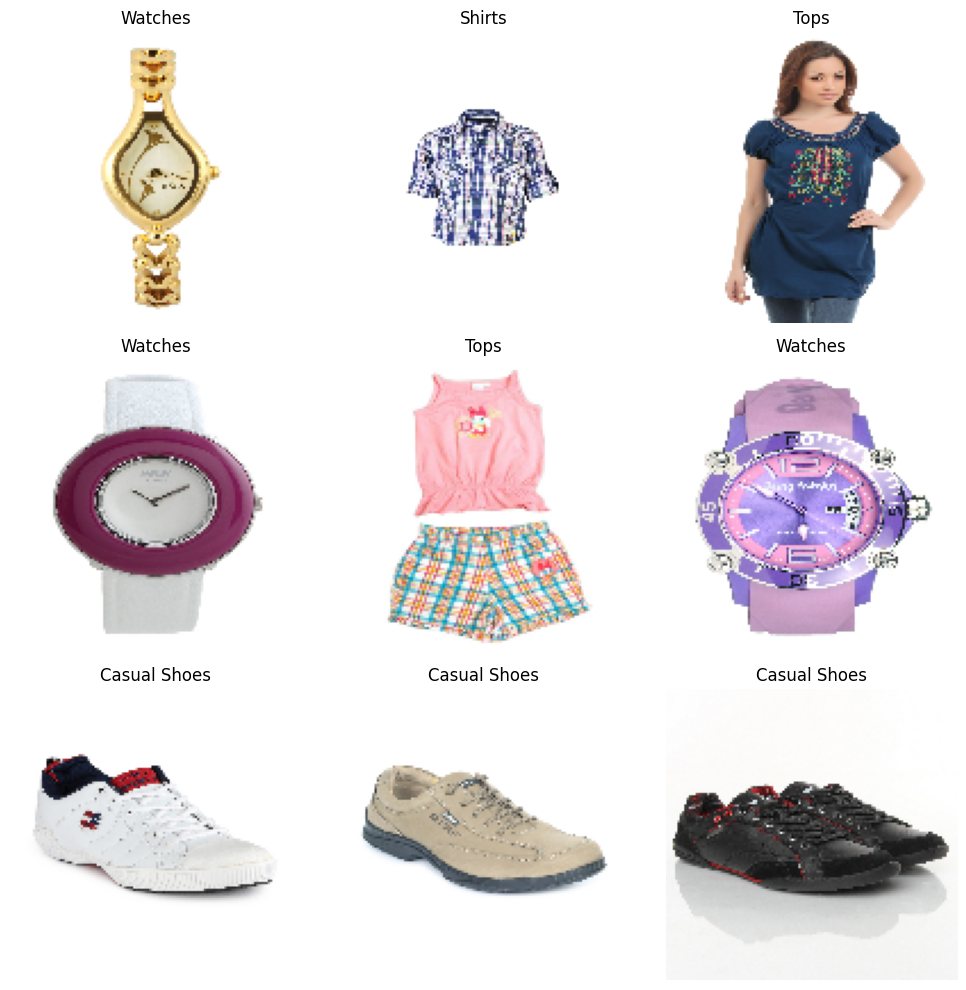

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(X_train[i])

    plt.title(
        label_encoder.inverse_transform([y_train[i]])[0]
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [52]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

**Data augmentation**

In [53]:
= ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

datagen.fit(X_train)

**CNN model development**

In [54]:
cnn_model = Sequential()

# Block 1
cnn_model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        padding='same',
        input_shape=(128,128,3)
    )
)

cnn_model.add(BatchNormalization())

cnn_model.add(MaxPooling2D((2,2)))

# Block 2
cnn_model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu',
        padding='same'
    )
)

cnn_model.add(BatchNormalization())

cnn_model.add(MaxPooling2D((2,2)))

# Block 3
cnn_model.add(
    Conv2D(
        128,
        (3,3),
        activation='relu',
        padding='same'
    )
)

cnn_model.add(BatchNormalization())

cnn_model.add(MaxPooling2D((2,2)))

# Flatten
cnn_model.add(Flatten())

# Dense Layer
cnn_model.add(Dense(256, activation='relu'))

cnn_model.add(Dropout(0.5))

# Output Layer
cnn_model.add(Dense(7, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [55]:
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,484,807 (32.37 MB)

 Trainable params: 8,484,359 (32.37 MB)

 Non-trainable params: 448 (1.75 KB)

In [56]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

**Model training**

In [57]:
= cnn_model.fit(
    datagen.flow(
        X_train,
        y_train,
        batch_size=32
    ),
    validation_data=(X_val, y_val),
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 22s 170ms/step - accuracy: 0.4042 - loss: 3.7694 - val_accuracy: 0.2992 - val_loss: 5.5649
Epoch 2/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 10s 110ms/step - accuracy: 0.4690 - loss: 1.3775 - val_accuracy: 0.5561 - val_loss: 1.4183
Epoch 3/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 10s 108ms/step - accuracy: 0.5460 - loss: 1.1619 - val_accuracy: 0.5252 - val_loss: 1.2199
Epoch 4/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 10s 110ms/step - accuracy: 0.5617 - loss: 1.0870 - val_accuracy: 0.5626 - val_loss: 1.1137
Epoch 5/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 10s 107ms/step - accuracy: 0.5749 - loss: 1.0351 - val_accuracy: 0.5512 - val_loss: 1.0754
Epoch 6/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 10s 109ms/step - accuracy: 0.5916 - loss: 1.0144 - val_accuracy: 0.6699 - val_loss: 0.8517
Epoch 7/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 10s 107ms/step - accuracy: 0.6150 - loss: 0.9649 - val_accuracy: 0.7024 - val_loss: 0.7963
Epoch 8/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 10s 108ms/step - accuracy: 0.6481 - loss: 0.8725 - val_accu

In [59]:
.save('my_model.keras')

print("CNN Model Saved")

CNN Model Saved


**Model evaluation**

In [60]:
, test_accuracy = cnn_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Loss :", test_loss)
print("Test Accuracy :", test_accuracy)

Test Loss : 0.6773536205291748
Test Accuracy : 0.7727272510528564


**Accuracy/loss curves**

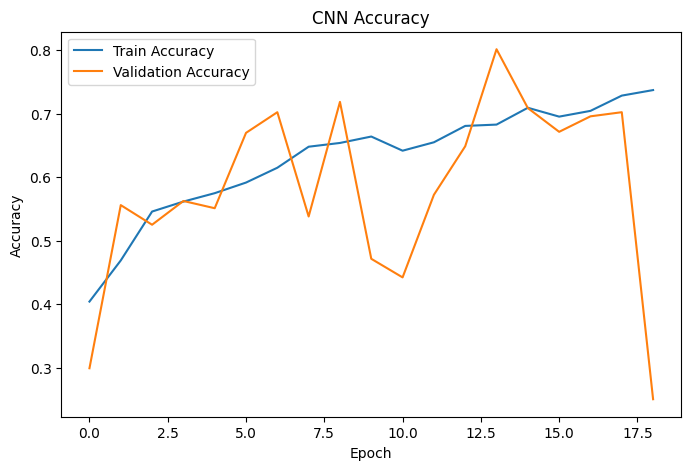

In [61]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("CNN Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.savefig("cnn_accuracy_curve.png")

plt.show()

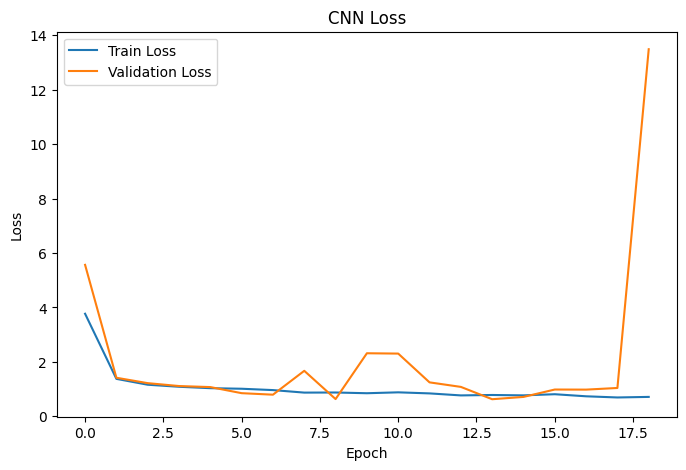

In [62]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='Train Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title("CNN Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.savefig("cnn_loss_curve.png")

plt.show()

In [63]:
y_pred_prob = cnn_model.predict(X_test)

y_pred = np.argmax(
    y_pred_prob,
    axis=1
)

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step


**Classification report**

In [64]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

Casual Shoes       1.00      0.90      0.94       105
       Jeans       0.88      1.00      0.93        91
      Shirts       0.81      0.67      0.73       105
        Tops       0.60      0.62      0.61       105
     Tshirts       0.54      0.76      0.63       105
     Watches       1.00      0.72      0.84       105

    accuracy                           0.77       616
   macro avg       0.80      0.78      0.78       616
weighted avg       0.80      0.77      0.78       616



**Confusion matrix**

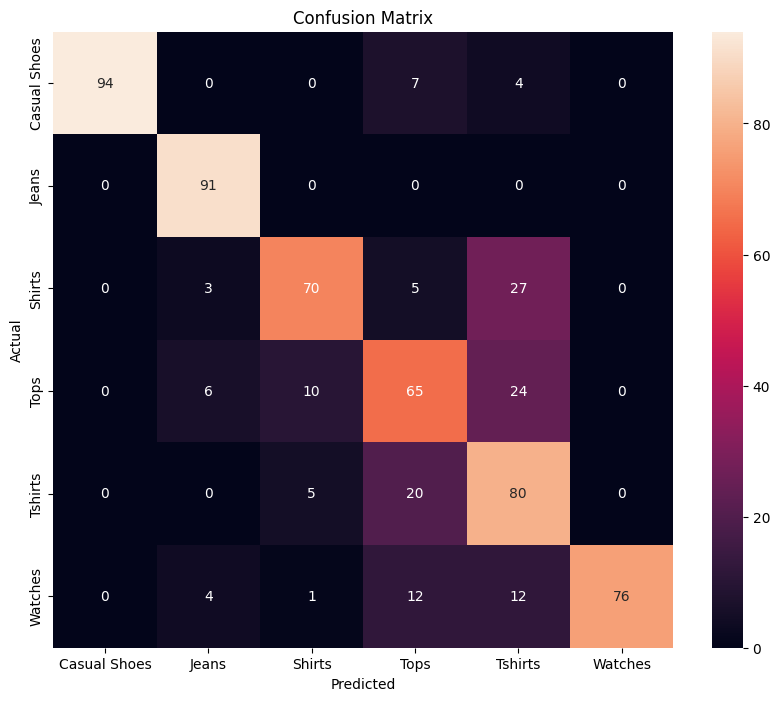

In [65]:
from sklearn.metrics import confusion_matrix

import seaborn as sns

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.savefig("cnn_confusion_matrix.png")

plt.show()

**Comparison with one transfer learning model**

In [66]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, Model

In [73]:
= MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128, 128, 3)   # MUST MATCH CNN_train
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [74]:
x = layers.GlobalAveragePooling2D()(base_model.output)

x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.4)(x)

output = layers.Dense(7, activation='softmax')(x)

tl_model = Model(inputs=base_model.input, outputs=output)

In [75]:
tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [76]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True
)

datagen.fit(X_train)

In [77]:
= tl_model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_val, y_val),
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10


2026-06-08 09:30:33.607783: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-08 09:30:33.744543: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


27/90 ━━━━━━━━━━━━━━━━━━━━ 6s 107ms/step - accuracy: 0.2350 - loss: 2.0981

2026-06-08 09:30:47.466834: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-08 09:30:47.602892: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - accuracy: 0.4092 - loss: 1.6175

2026-06-08 09:31:09.573800: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-08 09:31:09.710214: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


90/90 ━━━━━━━━━━━━━━━━━━━━ 52s 398ms/step - accuracy: 0.5923 - loss: 1.1600 - val_accuracy: 0.9057 - val_loss: 0.4468
Epoch 2/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 10s 114ms/step - accuracy: 0.8568 - loss: 0.4687 - val_accuracy: 0.9268 - val_loss: 0.2689
Epoch 3/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 10s 115ms/step - accuracy: 0.8861 - loss: 0.3494 - val_accuracy: 0.9317 - val_loss: 0.2136
Epoch 4/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 10s 116ms/step - accuracy: 0.9003 - loss: 0.2925 - val_accuracy: 0.9268 - val_loss: 0.2099
Epoch 5/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 10s 115ms/step - accuracy: 0.9038 - loss: 0.2837 - val_accuracy: 0.9398 - val_loss: 0.1793
Epoch 6/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 10s 115ms/step - accuracy: 0.9059 - loss: 0.2571 - val_accuracy: 0.9333 - val_loss: 0.1770
Epoch 7/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 10s 115ms/step - accuracy: 0.9220 - loss: 0.2424 - val_accuracy: 0.9366 - val_loss: 0.1697
Epoch 8/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 10s 116ms/step - accuracy: 0.9213 - loss: 0.2341 - val_accuracy: 0.943

In [78]:
test_loss, test_acc = tl_model.evaluate(X_test, y_test)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9294 - loss: 0.1861

2026-06-08 09:33:43.118005: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-08 09:33:43.253558: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 523ms/step - accuracy: 0.9367 - loss: 0.1900
Test Accuracy: 0.9366883039474487
Test Loss: 0.19004729390144348


**CNN vs Transfer Learning Comparison**

In [79]:
cnn_loss, cnn_acc = cnn_model.evaluate(X_test, y_test)

tl_loss, tl_acc = tl_model.evaluate(X_test, y_test)

print("CNN Accuracy:", cnn_acc)
print("CNN Loss:", cnn_loss)

print("Transfer Learning Accuracy:", tl_acc)
print("Transfer Learning Loss:", tl_loss)

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7727 - loss: 0.6774
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9367 - loss: 0.1900
CNN Accuracy: 0.7727272510528564
CNN Loss: 0.6773536205291748
Transfer Learning Accuracy: 0.9366883039474487
Transfer Learning Loss: 0.19004729390144348


In [81]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["CNN", "Transfer Learning (MobileNetV2)"],
    "Test Accuracy": [cnn_acc, tl_acc],
    "Test Loss": [cnn_loss, tl_loss]
})

print(comparison)

                             Model  Test Accuracy  Test Loss
0                              CNN       0.772727   0.677354
1  Transfer Learning (MobileNetV2)       0.936688   0.190047


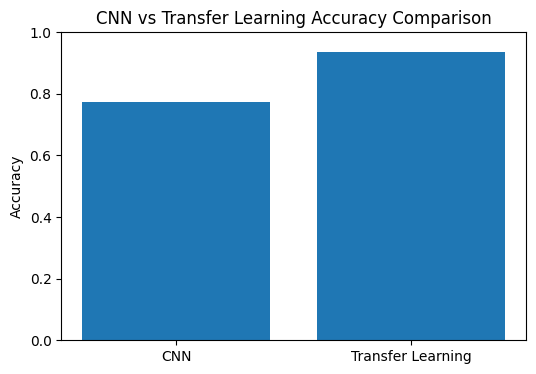

In [82]:
import matplotlib.pyplot as plt

models = ["CNN", "Transfer Learning"]
accuracy = [cnn_acc, tl_acc]

plt.figure(figsize=(6,4))
plt.bar(models, accuracy)
plt.title("CNN vs Transfer Learning Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

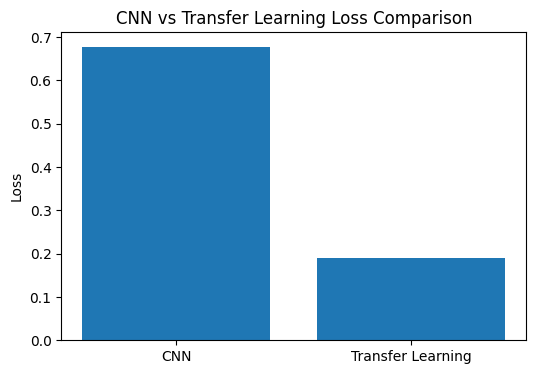

In [83]:
losses = [cnn_loss, tl_loss]

plt.figure(figsize=(6,4))
plt.bar(models, losses)
plt.title("CNN vs Transfer Learning Loss Comparison")
plt.ylabel("Loss")
plt.show()